# Современные методы анализа данных и машинного обучения, БИ

## НИУ ВШЭ, 2025-26 учебный год

## Групповой проект №5. Deep Learning

## Часть предобработки для MLP для определения полезности блюда

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import os
import matplotlib.image as mpimg
from PIL import Image
from PIL import ImageStat

In [85]:
mlp_df = pd.read_csv('cleaned_openfoodfacts.csv',sep='\t')
mlp_df

/var/folders/68/2f1nyxmn73d7lfzp1b94n9s00000gn/T/ipykernel_1247/2207554348.py:1: DtypeWarning:

Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.



,code,states_en,url,created_datetime,last_modified_datetime,creator,pnns_groups_2,countries_en,pnns_groups_1,product_name,...,sugars_100g,salt_100g,sodium_100g,saturated-fat_100g,categories_en,main_category_en,nutriscore_score,nutriscore_grade,fiber_100g,fruits-vegetables-rate_100g
0,3760029248001,"To be checked,Complete,Nutrition facts complet...",http://world-en.openfoodfacts.org/product/3760...,2012-01-31 14:43:58,2018-08-30 21:14:54,stephane,sweets,France,sugary snacks,Caramels tendres au beurre salé au sel de Guér...,...,49.3000,1.700000,0.680000,7.0000,"Groceries,Snacks,Sweet snacks,Confectioneries,...",Caramels,28.0,e,1.0,25
1,3029330062806,"To be completed,Nutrition facts completed,Ingr...",http://world-en.openfoodfacts.org/product/3029...,2012-02-09 10:34:56,2016-12-23 16:38:19,stephane,appetizers,France,salty snacks,Jacquet Les bouchées créatives à garnir,...,2.0000,1.752600,0.701040,1.3000,"Snacks,Salty snacks,Appetizers,Crackers",Crackers,10.0,c,3.0,25
2,3257980112590,"To be completed,Nutrition facts completed,Ingr...",http://world-en.openfoodfacts.org/product/3257...,2012-02-11 14:51:07,2021-02-22 22:39:03,marianne,biscuits and cakes,France,sugary snacks,Boudoirs aux œufs frais,...,51.8000,0.090000,0.036000,1.2000,"Snacks,Sweet snacks,Biscuits and cakes,Biscuit...",Sponge fingers biscuit,14.0,d,1.6,25
3,3017760038409,"To be completed,Nutrition facts completed,Ingr...",http://world-en.openfoodfacts.org/product/3017...,2012-02-11 15:07:23,2021-02-02 20:38:52,marianne,biscuits and cakes,"Belgium,Canada,France,Switzerland",sugary snacks,Lulu La Barquette Fraise,...,58.0000,0.090000,0.036000,0.6000,"Snacks,Sweet snacks,Biscuits and cakes,Biscuit...",fr:Barquettes à la fraise,13.0,d,1.7,25
4,3160181210524,"To be checked,Complete,Nutrition facts complet...",http://world-en.openfoodfacts.org/product/3160...,2012-02-11 18:51:58,2019-08-23 19:57:37,stephane,biscuits and cakes,France,sugary snacks,Cookies tout chocolat Biocoop,...,33.0000,0.381000,0.152400,14.0000,"Snacks,Sweet snacks,Biscuits and cakes,Biscuit...",Chocolate biscuits,19.0,e,5.5,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1079097,9310846500079,"To be completed,Nutrition facts completed,Ingr...",http://world-en.openfoodfacts.org/product/9310...,2021-03-29 00:10:18,2021-03-29 00:10:20,kiliweb,unknown,Australia,unknown,HiProtein Mixed Berry Milk Chon,...,23.3333,0.675000,0.232000,2.8333,unknown,unknown,NaN,NaN,2.1,45
1079098,0772575409327,"To be completed,Nutrition facts completed,Ingr...",http://world-en.openfoodfacts.org/product/0772...,2021-03-29 00:12:21,2021-03-29 00:12:21,kiliweb,unknown,Canada,unknown,Nothing but cheese monterey jack,...,0.0000,2.638889,1.055556,25.0000,unknown,unknown,NaN,NaN,2.1,45
1079099,0743709000888,"To be completed,Nutrition facts completed,Ingr...",http://world-en.openfoodfacts.org/product/0743...,2021-03-29 00:23:55,2021-03-29 00:23:56,kiliweb,unknown,United States,unknown,Parboiled Long Grain,...,0.0000,0.000000,0.000000,0.0000,unknown,unknown,NaN,NaN,2.1,45
1079100,0627987447859,"To be completed,Nutrition facts completed,Ingr...",http://world-en.openfoodfacts.org/product/0627...,2021-03-29 00:24:13,2021-03-29 00:24:14,kiliweb,unknown,Canada,unknown,Granola Biologique,...,12.7273,0.727273,0.290909,3.6364,unknown,unknown,NaN,NaN,2.1,45


В качестве целевой переменной выберем 'nutriscore_grade' - показатель пищевой ценности продукта по шкале от A(наилучший) до E(наихудший). 

*Это европейская система маркировки, которая показывает насколько продукт сбалансирован по составу

In [86]:
mlp_df['nutriscore_grade']

0            e
1            c
2            d
3            d
4            e
          ... 
1079097    NaN
1079098    NaN
1079099    NaN
1079100    NaN
1079101    NaN
Name: nutriscore_grade, Length: 1079102, dtype: object

В качестве признаков оставим только показатели пищевой ценности продукта. 

In [87]:
features=['energy_100g','fat_100g','saturated-fat_100g','carbohydrates_100g','sugars_100g','fiber_100g','proteins_100g','salt_100g','sodium_100g']

In [88]:
mlp_df=mlp_df[features+['nutriscore_grade']]
mlp_df

,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutriscore_grade
0,1717.0,10.9000,7.0000,73.5000,49.3000,1.0,3.0000,1.700000,0.680000,e
1,1898.0,15.5000,1.3000,68.0000,2.0000,3.0,8.5000,1.752600,0.701040,c
2,1615.0,3.2000,1.2000,80.4000,51.8000,1.6,6.9000,0.090000,0.036000,d
3,1487.0,2.0000,0.6000,78.0000,58.0000,1.7,3.8000,0.090000,0.036000,d
4,2040.0,25.0000,14.0000,56.0000,33.0000,5.5,7.0000,0.381000,0.152400,e
...,...,...,...,...,...,...,...,...,...,...
1079097,1563.0,8.1667,2.8333,59.6667,23.3333,2.1,15.1667,0.675000,0.232000,NaN
1079098,2324.0,38.8889,25.0000,16.6667,0.0000,2.1,38.8889,2.638889,1.055556,NaN
1079099,1488.0,0.0000,0.0000,77.7778,0.0000,2.1,6.6667,0.000000,0.000000,NaN
1079100,1750.0,20.0000,3.6364,54.5455,12.7273,2.1,9.0909,0.727273,0.290909,NaN


Проверим наличие пропусков:

In [89]:
mlp_df.isna().sum()

energy_100g                0
fat_100g                   0
saturated-fat_100g         0
carbohydrates_100g         0
sugars_100g                0
fiber_100g                 0
proteins_100g              0
salt_100g                  0
sodium_100g                0
nutriscore_grade      556150
dtype: int64

Удалим строки с пропусками целевой переменной 'nutriscore_grade' 

In [90]:
mlp_df=mlp_df.dropna(subset=['nutriscore_grade'])

In [91]:
mlp_df.isna().sum()

energy_100g           0
fat_100g              0
saturated-fat_100g    0
carbohydrates_100g    0
sugars_100g           0
fiber_100g            0
proteins_100g         0
salt_100g             0
sodium_100g           0
nutriscore_grade      0
dtype: int64

Больше пропусков нет

In [92]:
mlp_df['nutriscore_grade'].value_counts()

nutriscore_grade
d    161218
c    111525
e     99309
a     83032
b     67868
Name: count, dtype: int64

Рассмотрим наличие дубликатов 

In [93]:
mlp_df[mlp_df.duplicated()]

,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutriscore_grade
108,226.0,0.0,0.0,13.0,13.0,0.0,0.0,0.00,0.000,e
384,1700.0,0.0,0.0,100.0,100.0,0.0,0.0,0.00,0.000,d
556,1548.0,2.0,0.4,72.0,3.7,3.6,13.0,0.01,0.004,a
590,933.0,15.0,3.3,0.0,0.0,0.0,22.0,1.00,0.400,c
687,195.0,1.6,1.0,4.8,4.8,0.0,3.2,0.10,0.040,b
...,...,...,...,...,...,...,...,...,...,...
1076828,1761.0,41.0,28.0,1.0,1.0,0.0,12.0,1.30,0.520,d
1076863,1700.0,0.0,0.0,100.0,100.0,0.0,0.0,0.00,0.000,d
1077091,1113.0,13.0,1.5,32.0,30.0,0.2,3.0,2.20,0.880,e
1077199,1448.0,28.0,20.0,1.5,0.0,0.0,22.0,1.80,0.720,d


Исходный датасет содержит много объектов (более миллиона), поэтому наличие дубликатов довольно ожидаемо. Так как дублирующиеся строки не несут новой информации и могут приводить к переобучению, все полные дубликаты удалим

In [94]:
mlp_df = mlp_df.drop_duplicates()


In [95]:
mlp_df[mlp_df.duplicated()]

,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutriscore_grade


Для более качественного обучения модели удалим выбросы по правилу 1.5 IQR

In [96]:
for col in features:
  q1=mlp_df[col].quantile(0.25)
  q3=mlp_df[col].quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr
  mlp_df=mlp_df[(mlp_df[col]>=lower_bound)&(mlp_df[col]<=upper_bound)]

In [97]:
mlp_df.shape

(297376, 10)

## EDA для табличных данных

In [34]:
mlp_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297376 entries, 1 to 1078834
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   energy_100g         297376 non-null  float64
 1   fat_100g            297376 non-null  float64
 2   saturated-fat_100g  297376 non-null  float64
 3   carbohydrates_100g  297376 non-null  float64
 4   sugars_100g         297376 non-null  float64
 5   fiber_100g          297376 non-null  float64
 6   proteins_100g       297376 non-null  float64
 7   salt_100g           297376 non-null  float64
 8   sodium_100g         297376 non-null  float64
 9   nutriscore_grade    297376 non-null  object 
dtypes: float64(9), object(1)
memory usage: 25.0+ MB


Все отобранные признаки представлены вещественными числами (float), а целевая переменная (nutriscore_grade) - категориальный признак, показывающий пищевую ценность продукта по шкале от A(наилучший) до E(наихудший)

In [35]:
print('Количество пропусков в каждом признаке:')
mlp_df.isna().sum()

Количество пропусков в каждом признаке:


energy_100g           0
fat_100g              0
saturated-fat_100g    0
carbohydrates_100g    0
sugars_100g           0
fiber_100g            0
proteins_100g         0
salt_100g             0
sodium_100g           0
nutriscore_grade      0
dtype: int64

После предобработки еще раз убедились, что в датасете отсутвуют пропуски.

In [36]:
round(mlp_df.describe(), 2)

,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
count,297376.00,297376.00,297376.00,297376.00,297376.00,297376.00,297376.00,297376.00,297376.00
mean,929.40,9.75,3.25,26.14,9.47,1.76,6.72,0.75,0.30
std,657.59,10.58,4.07,24.48,11.46,1.81,5.76,0.70,0.28
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,355.00,1.10,0.10,5.80,1.20,0.00,2.01,0.10,0.04
50%,812.00,5.81,1.60,15.70,4.00,1.50,5.51,0.64,0.26
75%,1469.00,16.00,4.84,46.67,13.60,2.50,10.00,1.20,0.48
max,3502.00,51.90,16.75,100.00,45.70,7.50,24.20,2.84,1.14


Все значения находятся в пределах нормы и соответствуют реальности. Единственное, автор датасета не оставил описание признаков, но они все достаточно очевидные для интерпретации, но energy_100g может быть указан как в ккал, так и в кДж, тк максимально возможная калорийность продукта ~900, что превышает даже среднее energy_100g, но хорошо совпадает с распределением кДж, то для более удобной дальнейшей работы переведем значения к ккал

In [37]:
mlp_df['energy_100g'] = mlp_df['energy_100g'] / 4.184

Теперь проанализируем целевую переменную, рассмотрев баланс классов:

In [38]:
healthy_group = mlp_df['nutriscore_grade'].value_counts().reset_index().sort_values(by='nutriscore_grade')
fig = px.pie(healthy_group, names='nutriscore_grade', values='count', title='Распредение целевой переменной (nutriscore_grade)')
fig.show()

Если рассматривать "С" как погрничную категорию, то "А" и "В" (более полезные продукты/блюда) составляют значительно мееьшую долю, чем "D" и "E", что соответсвует реальности, так как на рынке сейчас представлено больше вредных продуктов. Тем не менее, все категории содержат достаточное количество объектов для обучения

Для более корректного и полного анализа создадим признаки равные долям бжу относительно калорийности. Для правильного рассчета долей с учетом энергетической ценности - жиры домножим на 9, а белки и углеводы на 4. Таким образом можно будет оценить вклад каждого нутриена в общую калорийность.

In [40]:
mlp_df['fat_cal_raio'] = (mlp_df['fat_100g']*9) / mlp_df['energy_100g']
mlp_df['protein_cal_raio'] = (mlp_df['proteins_100g']*4) / mlp_df['energy_100g']
mlp_df['carbs_cal_raio'] = (mlp_df['carbohydrates_100g']*4) / mlp_df['energy_100g']
mlp_df

,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutriscore_grade,fat_cal_raio,protein_cal_raio,carbs_cal_raio
1,453.632887,15.5,1.30,68.0,2.00,3.00,8.50,1.7526,0.70104,c,0.307517,0.074950,0.599604
4,487.571702,25.0,14.00,56.0,33.00,5.50,7.00,0.3810,0.15240,e,0.461471,0.057427,0.459420
8,255.975143,20.1,4.14,0.9,0.90,0.00,17.10,0.7000,0.28000,c,0.706709,0.267213,0.014064
9,336.759082,29.5,5.30,0.7,0.70,0.00,17.40,0.6000,0.24000,d,0.788397,0.206676,0.008315
10,221.080306,17.3,3.36,2.2,0.30,2.20,13.50,2.2750,0.91000,d,0.704269,0.244255,0.039805
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077927,184.751434,3.5,1.40,30.0,2.00,2.00,6.90,1.4000,0.56000,c,0.170499,0.149390,0.649521
1078129,51.864245,2.8,0.30,4.5,4.00,2.30,1.20,0.6200,0.24800,b,0.485884,0.092549,0.347060
1078143,91.061185,0.0,0.00,13.4,12.80,0.00,8.10,0.2500,0.10000,a,0.000000,0.355805,0.588615
1078791,326.720841,29.0,11.00,2.3,0.60,0.50,15.00,1.8400,0.73600,e,0.798847,0.183643,0.028159


Чтобы исправить случаи деления на ноль (есть блюда с нулевой калорийностью), где доли становятся равны бесконечности, заменим эти значения на 0.

In [41]:
mlp_df['fat_cal_raio'] = mlp_df.apply(lambda x: 0 if x.loc['energy_100g']==0 else x['fat_cal_raio'], axis=1)
mlp_df['carbs_cal_raio'] = mlp_df.apply(lambda x: 0 if x.loc['energy_100g']==0 else x['carbs_cal_raio'], axis=1)
mlp_df['protein_cal_raio'] = mlp_df.apply(lambda x: 0 if x.loc['energy_100g']==0 else x['protein_cal_raio'], axis=1)

Для анализа взаимосвязей между признаками и их связи с целевой переменной, воспользуемся корреляционным анализом. Так как коэффициент корреляции Пирсона позволяет находить только линейные зависимости, рассмотрим коэффициент корреляции Спирмена, который находит именно монотонные связи

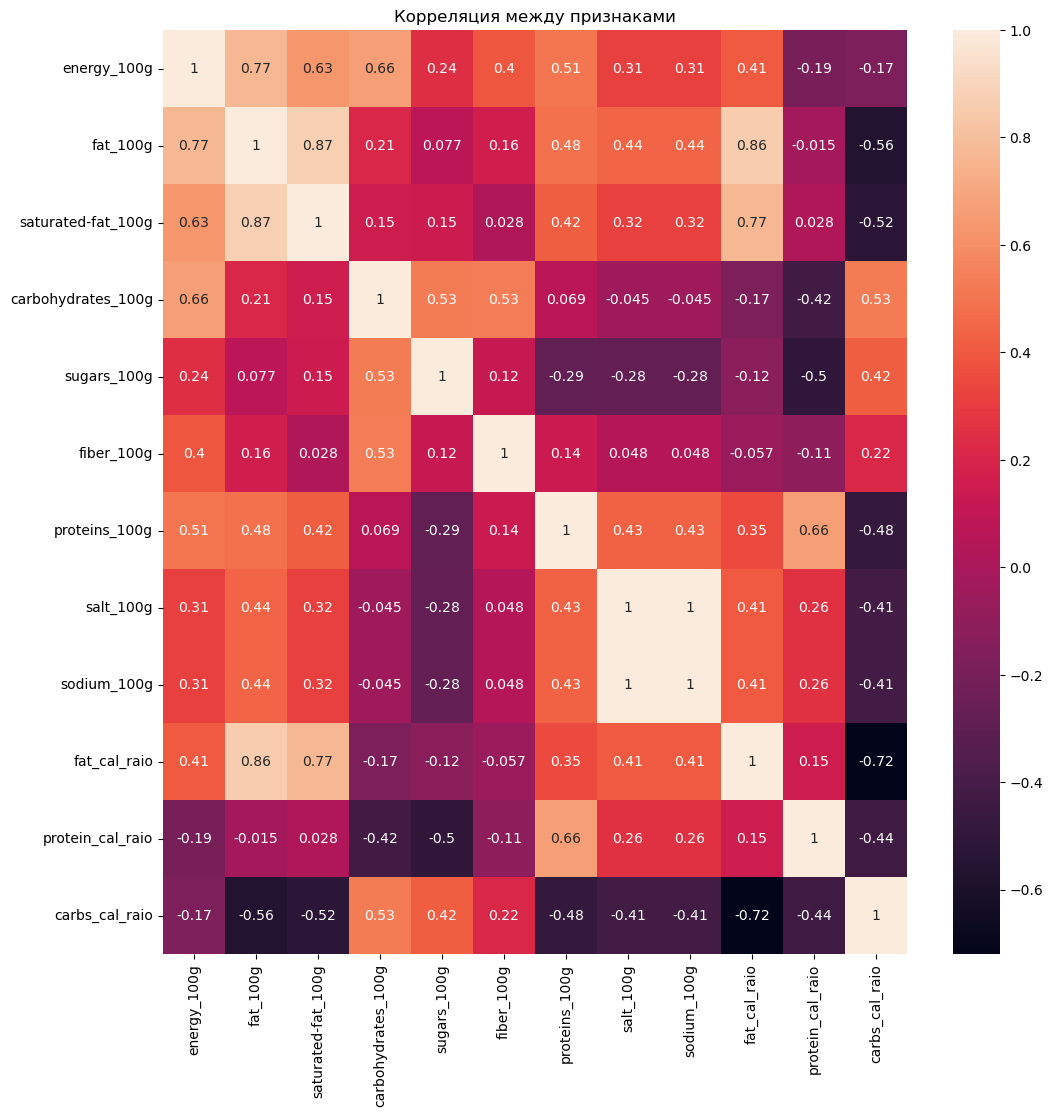

In [42]:
nutrients = mlp_df.drop('nutriscore_grade', axis=1)
nutrients_corr = nutrients.corr(method='spearman')
plt.figure(figsize=(12, 12))
sns.heatmap(nutrients_corr, annot=True)
plt.title('Корреляция между признаками')
plt.show()

Получили, что корреляция между солью и натрием на 100г равна 1, что очевидно исходя из состава соли, поэтому стоит удалить один из признаков. Соль - более интерпретируемая, поэтому ее оставим.

Также высокая корреляция у признаков - жиры и насыщенные жиры, создадим новый признак - доля насыщенных жиров, а сам признак удалим.

fat_cal_ratio и fat_100g сильно коррелируют (>0.8), и fat_100g имеет высокую корреляцию с energy_100g. Чтобы уменьшить мультиколлинеарность, оставляем fat_cal_ratio как более содержательный признак, а fat_100g удаляем

In [43]:
mlp_df['saturated_fat_ratio'] = mlp_df['saturated-fat_100g'] / mlp_df['fat_100g']
mlp_df['saturated_fat_ratio'] = mlp_df.apply(lambda x: 0 if x.loc['fat_100g']==0 else x['saturated_fat_ratio'], axis=1)
mlp_df.drop(labels=['saturated-fat_100g'], axis=1, inplace=True)
mlp_df.drop(labels=['sodium_100g'], axis=1, inplace=True)
mlp_df.drop(labels=['fat_100g'], axis=1, inplace=True)

In [44]:
mlp_df.isna().sum().sum()

0

После преобразований пропусков не появилось.

Теперь рассмотрим корреляцию признаков именно с целевой переменной

In [67]:
le = LabelEncoder()
nutriscore = le.fit_transform(mlp_df['nutriscore_grade'])
target_df = mlp_df
target_df['nutriscore_grade'] = nutriscore

target_corr = target_df.corr(method='spearman')['nutriscore_grade'].sort_values()
target_corr = round(target_corr, 2)
print('Корреляции признаков с целевой переменной:')
target_corr


Корреляции признаков с целевой переменной:


protein_cal_raio      -0.37
fiber_100g            -0.13
carbs_cal_raio        -0.10
proteins_100g          0.04
carbohydrates_100g     0.22
saturated_fat_ratio    0.27
salt_100g              0.28
fat_cal_raio           0.36
sugars_100g            0.38
energy_100g            0.47
nutriscore_grade       1.00
Name: nutriscore_grade, dtype: float64

Некоторые признаки показали незначительную связь с целевой переменной. Но удалять их не будем, тк для обучения будем использовать нелинейные модели, которые могут выявлять и сложные зависимости. Например, в последнее время многие врачи напоминают о важности достаточного потребления клечатки, что по сути должно влиять на полезность блюда, хотя по корреляции это не подтвреждается.


In [55]:
y=mlp_df['nutriscore_grade'].values
x=mlp_df.drop(labels=['nutriscore_grade'], axis=1).values

In [56]:
X_train_val,X_test,y_train_val,y_test=train_test_split(x,y,test_size=0.15,random_state=42,stratify=y)

In [57]:
X_train,X_val,y_train,y_val=train_test_split(X_train_val,y_train_val,test_size=0.176,random_state=42,stratify=y_train_val)

In [58]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [59]:
X_val=scaler.transform(X_val)
X_test=scaler.transform(X_test)

In [60]:
le = LabelEncoder()
y_train=le.fit_transform(y_train)
y_val=le.transform(y_val)
y_test=le.transform(y_test)

In [61]:
X_train.shape

(208281, 10)

In [62]:
y_train.shape

(208281,)

In [63]:
X_val.shape

(44488, 10)

In [64]:
y_val.shape

(44488,)

In [65]:
X_test.shape

(44607, 10)

In [66]:
y_test.shape

(44607,)

## EDA для СNN

Сначала рассмотрим, сколько изображений каждого класса есть в train и test

In [59]:
path_food = "food11"
path_train = os.path.join(path_food, "train")
categories_food = os.listdir(path_train)
names_train = []
counts_train = []
for category in categories_food:
    if category == '.DS_Store':
        continue
    path_category_train = os.path.join(path_train, category)
    all_img = os.listdir(path_category_train)
    count_cat = len(all_img)
    names_train.append(category)
    counts_train.append(count_cat)

data_train = pd.DataFrame({'Name': names_train, 'Count': counts_train})
data_train

,Name,Count
0,ice_cream,900
1,chicken_curry,900
2,cheesecake,900
3,hot_dog,900
4,apple_pie,900
5,omelette,900
6,sushi,900
7,hamburger,900
8,pizza,900
9,french_fries,900


In [61]:
path_test = os.path.join(path_food, "test")
categories_food = os.listdir(path_test)
names_test = []
counts_test = []
for category in categories_food:
    if category == '.DS_Store':
        continue
    path_category_test = os.path.join(path_test, category)
    all_img = os.listdir(path_category_test)
    count_cat = len(all_img)
    names_test.append(category)
    counts_test.append(count_cat)

data_test = pd.DataFrame({'Name': names_test, 'Count': counts_test})
data_test

,Name,Count
0,ice_cream,100
1,chicken_curry,100
2,cheesecake,100
3,hot_dog,100
4,apple_pie,100
5,omelette,100
6,sushi,100
7,hamburger,100
8,pizza,100
9,french_fries,100


In [63]:
print('Количество изображений в обучающей выборке всего:', data_train['Count'].sum())
print('Количество изображений в тестовой выборке всего:', data_test['Count'].sum())
print('Количество изображений в обеих выборках всего:', data_train['Count'].sum()+data_test['Count'].sum())

Количество изображений в обучающей выборке всего: 9900
Количество изображений в тестовой выборке всего: 1100
Количество изображений в обеих выборках всего: 11000


In [21]:
for_pie = pd.DataFrame({'names':['train', 'test'], 'values':[data_train['Count'].sum(), data_test['Count'].sum()]})
fig = px.pie(for_pie, values='values', names='names', title='Соотношение обучающей и тестовой выборок')
fig.show()

В обучающей и тестовой выборках по 11 одинаковых видов блюд, в первой по 900 изображений на блюдо, во второй - по 100. Изображения распределены равномерно.
Всего 11000 изображений, из которых 10% - тестовая выборка и 90% - обучающая

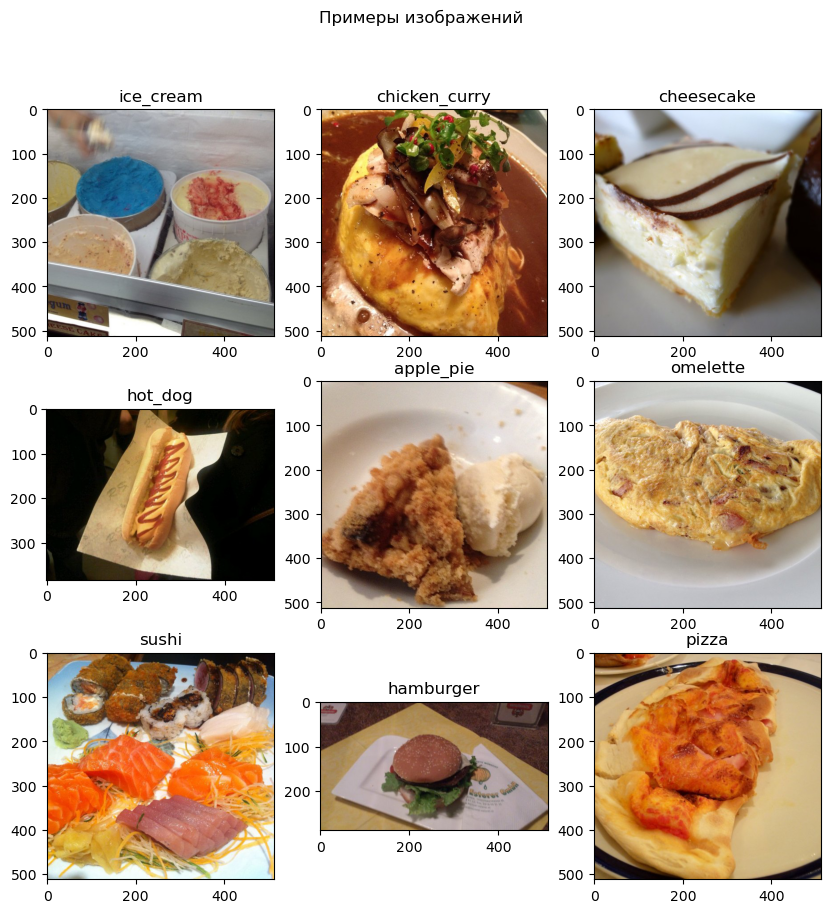

In [53]:
plt.figure(figsize=(10, 10))
list_categories = [i for i in os.listdir(path_train) if i != ".DS_Store"]
for i, category in enumerate(list_categories[:9]):  
    plt.subplot(3, 3, i+1)
    path_category = os.path.join("food11/train", category)
    first_i = os.listdir(path_category)[0]
    img_path = os.path.join(path_category, first_i)
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.title(category)
plt.suptitle('Примеры изображений')
plt.show()


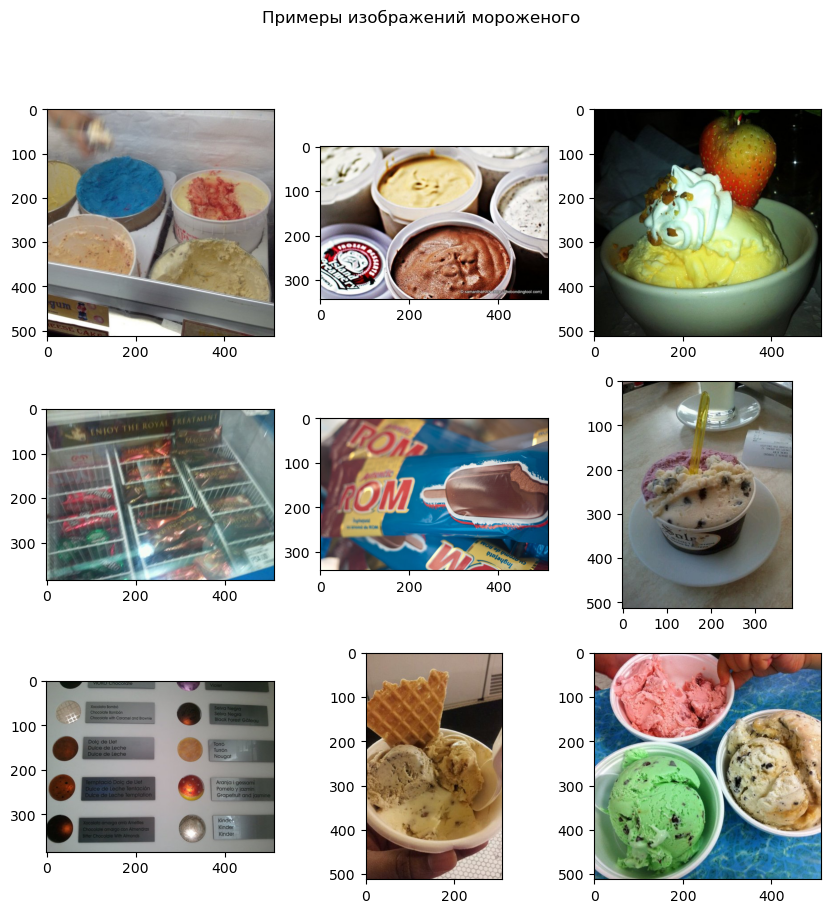

In [57]:
plt.figure(figsize=(10, 10))
first_cat = list_categories[0]
path_category = os.path.join("food11/train", first_cat)
for i in range(9):  
    plt.subplot(3, 3, i+1)
    img_i = os.listdir(path_category)[i]
    img_path = os.path.join(path_category, img_i)
    img = mpimg.imread(img_path)
    plt.imshow(img)
plt.suptitle('Примеры изображений мороженого')
plt.show()

Способ убрать ненужный файл ".DS_Store" был найдел тут: https://stackoverflow.com/questions/31943736/how-to-exclude-ds-store-from-file-count

Тут нашла способ отображение через matplotlib: https://stackoverflow.com/questions/35286540/how-to-display-an-image

Попробуем рассмотреть размеры нескольких изображений первого типа блюд

In [84]:
first_category = os.listdir(path_train)[0]
path_cat = os.path.join("food11/train",first_category)
paths_img = os.listdir(path_cat)

sizes = []
for name_img in paths_img:
    path_img = os.path.join(path_cat, name_img)
    im = Image.open(path_img)
    w, h = im.size
    sizes.append([w, h])

print('Размер первых 10 изображений:')
sizes[:10]
    

Размер первых 10 изображений:


[[512, 512],
 [512, 342],
 [512, 512],
 [512, 384],
 [512, 342],
 [384, 512],
 [512, 384],
 [308, 512],
 [512, 512],
 [512, 512]]

Источник, где был найден способ получения размера изображения: https://stackoverflow.com/questions/6444548/how-do-i-get-the-picture-size-with-pil

Видно, что значения разные, поэтому рассмотрим больше изображений

In [83]:
a = pd.DataFrame({'sizes':sizes})
a['sizes'].value_counts()[:5]

sizes
[512, 512]    550
[512, 384]    104
[384, 512]     86
[382, 512]     18
[511, 512]     12
Name: count, dtype: int64

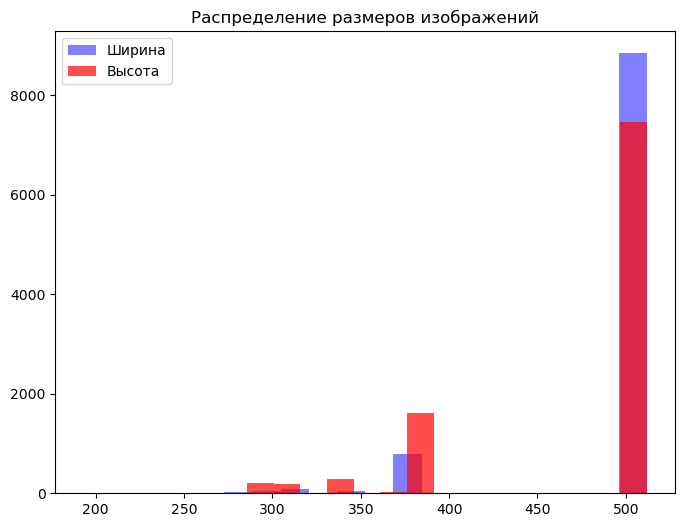

In [103]:
plt.figure(figsize=(8, 6))
widths = []
heights = []
for category in list_categories:
   path_category = os.path.join(path_train, category)
   names_ing = os.listdir(path_category)
   for name_ing in names_ing:
        path_img = os.path.join(path_category, name_ing)
        img = Image.open(path_img)
        w, h = img.size
        widths.append(w)
        heights.append(h)

plt.hist(widths, bins=20, color='b', alpha=0.5, label='Ширина')
plt.hist(heights, bins=20,  color='r',alpha=0.7, label='Высота')
plt.title('Распределение размеров изображений')
plt.legend()
plt.show()


In [99]:
print('Высота:')
print('Минимальной значение:', min(heights))
print('Максимальное значение:', max(heights))
print('Ширина:')
print('Минимальной значение:', min(widths))
print('Максимальное значение:', max(widths))

Высота:
Минимальной значение: 210
Максимальное значение: 512
Ширина:
Минимальной значение: 193
Максимальное значение: 512


Даже если оценивать минимальный размер - он является допустимым для качественного обучения.
Многие изображения 512х512, но есть и другие вариации, не все из них 1 к 1

In [105]:
brightness_list = []
for category in list_categories:
    path_category = os.path.join(path_train, category)
    names_ing = os.listdir(path_category)
    for name_ing in names_ing:
        path_img = os.path.join(path_category, name_ing)
        img = Image.open(path_img)
        stat = ImageStat.Stat(img)
        brightness_list.append(stat.mean[0])


print('Яркость изображений:')
print('Минимальная яркость:', min(brightness_list))
print('Максимальная яркость:', max(brightness_list))
print('Средняя яркость:', np.mean(brightness_list))
print()

res = np.array(brightness_list)
dark_mask = [res< 50]
bright_mask = [res> 200]
print('Количество очень темных:', np.sum(dark_mask))
print('Количество очень светлых:', np.sum(bright_mask))

Яркость изображений:
Минимальная яркость: 13.370025634765625
Максимальная яркость: 244.16822814941406
Средняя яркость: 142.7457375151316

Количество очень темных: 27
Количество очень светлых: 326


Источник, где показано, как определять яркость изображений: https://stackoverflow.com/questions/3490727/what-are-some-methods-to-analyze-image-brightness-using-python

## Часть предобработки для CNN для предсказания класса блюда

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import shutil
INPUT_DIR = "/content/drive/MyDrive/food11"
train_dir = os.path.join(INPUT_DIR, "train")
val_dir = os.path.join(INPUT_DIR, "val")
os.makedirs(val_dir) # нужно добавить физическую папку val и перенести туда часть картинок из train
for class_name in os.listdir(train_dir):
  class_train_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_train_path):
    class_val_path = os.path.join(val_dir, class_name)
    os.makedirs(class_val_path, exist_ok=True)
    all_images = [f for f in os.listdir(class_train_path) if f.endswith(".jpg")]
    val_images = all_images[:100]
    for img in val_images:
      shutil.move(os.path.join(class_train_path, img),os.path.join(class_val_path, img),)


In [75]:
import json
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from torchvision import transforms


In [76]:
#код взят с семинара
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])
DEVICE=(torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
BATCH_SIZE = 8

In [77]:
#код взят с семинара
data_transforms = {
    "train": transforms.Compose([
            transforms.Resize(256),#сначала меняем размер с запасом
            transforms.RandomCrop(224),#вырезаем случайную область 224x224
            transforms.RandomHorizontalFlip(),#зеркальное отражение по горизонтали
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),#нормализация
    ]),
    "val": transforms.Compose([  # На валидации и тесте только изменение размера и кроп по центру
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    "test": transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}

In [84]:
#код взят с семинара
dataset = {ds: torchvision.datasets.ImageFolder(
        root=os.path.join(INPUT_DIR, ds),
        transform=data_transforms[ds]
    ) for ds in ["train","val","test"]}

dataset_size={ds:len(dataset[ds]) for ds in ["train","val","test"]}
dataset_classes = dataset["train"].classes
print("classes:", dataset_classes, "\nsize", dataset_size)

classes: ['apple_pie', 'cheesecake', 'chicken_curry', 'french_fries', 'fried_rice', 'hamburger', 'hot_dog', 'ice_cream', 'omelette', 'pizza', 'sushi'] 
size {'train': 8812, 'val': 1100, 'test': 1100}


In [80]:
#код взят с семинара
dataloader = {
  "train": torch.utils.data.DataLoader(
      dataset=dataset["train"], batch_size=BATCH_SIZE, shuffle=True, num_workers=0
  ),
  "val": torch.utils.data.DataLoader(
      dataset=dataset["val"],batch_size=BATCH_SIZE,shuffle=False,num_workers=0,
  ),
  "test": torch.utils.data.DataLoader(
      dataset=dataset["test"],batch_size=BATCH_SIZE,shuffle=False,num_workers=0,
  ),
}

In [81]:
#код взят с семинара
def get_batches(dataloader, num_of_batches=3): #функция разиения по батчам
    assert num_of_batches > 0
    images, classes = next(iter(dataloader))
    for _ in range(num_of_batches - 1):
        image_batch, cls_batch = next(iter(dataloader))
        images = torch.cat([images, image_batch], dim=0)
        classes = torch.cat([classes, cls_batch], dim=0)
    return images, classes

In [82]:
#код взят с семинара
def show_batches(images, classes): #функция отрисовки батчей
  cols = (images.shape[0] + 3) // 4
  images = images.numpy().transpose(0, 2, 3, 1)
  images = images * IMAGENET_STD + IMAGENET_MEAN
  images = np.clip(images, 0, 1)
  fig, axes = plt.subplots(cols, 4, figsize=(12, cols * 3))
  for ax, img, img_cls in zip(axes.flatten(), images, classes.numpy()):
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_xlabel(dataset_classes[img_cls],fontsize=20)
  plt.tight_layout()
  plt.show()

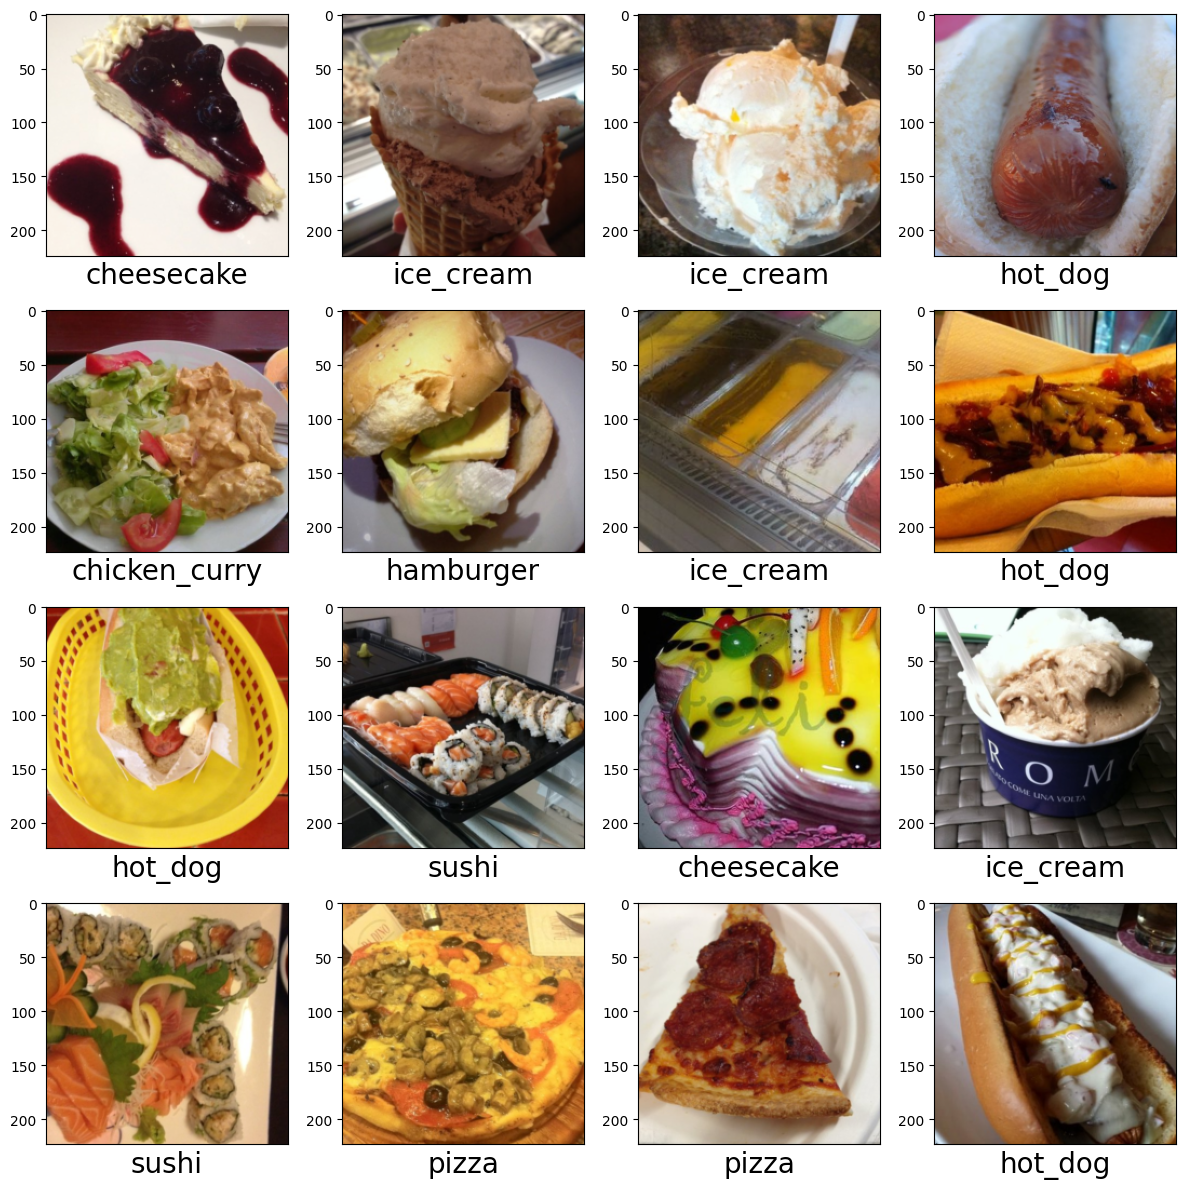

In [86]:
images, classes = get_batches(dataloader["train"],num_of_batches=2)
show_batches(images, classes)